# ANALYSES FOR THE OUTPUTS OF THE MODEL

In [34]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torchinfo
from torchinfo import summary
from torchview import draw_graph
import graphviz

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

# Drawing Model Summary

In [3]:
import efficientUnet

In [4]:
# Create model summary

model = efficientUnet.EfficientUNet(in_channels=7, num_classes=7)
summary = summary(model, input_size=(1, 7, 128, 128), depth=4,
                  col_names=["input_size", "output_size", "num_params", "trainable"])

# Save the model summary to a text file
output_file = Path("model_summary.txt")
with output_file.open("w") as f:
    f.write(str(summary))
print(summary)

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Trainable
EfficientUNet                                      [1, 7, 128, 128]          [1, 7, 128, 128]          --                        True
├─EfficientNetFeatures: 1-1                        [1, 7, 128, 128]          [1, 24, 64, 64]           --                        True
│    └─Conv2d: 2-1                                 [1, 7, 128, 128]          [1, 40, 64, 64]           2,520                     True
│    └─BatchNormAct2d: 2-2                         [1, 40, 64, 64]           [1, 40, 64, 64]           80                        True
│    │    └─Identity: 3-1                          [1, 40, 64, 64]           [1, 40, 64, 64]           --                        --
│    │    └─SiLU: 3-2                              [1, 40, 64, 64]           [1, 40, 64, 64]           --                        --
│    └─Sequential: 2-3                             --        

In [132]:
depth = 2

graph = draw_graph(
    model,
    input_size=(1, 7, 128, 128),
    expand_nested=False,  # Collapse nested modules
    depth=depth,
    graph_name="EfficientUNet",
    roll=True,
    save_graph=False
)

graph.visual_graph.attr(rankdir="TB")  # Top to Bottom
graph.visual_graph.attr(fontsize="8")
graph.visual_graph.attr('node', shape='box', style='rounded,filled', fillcolor='lightgray', fontsize="8", width="0.4", height="0.2")

graph.visual_graph.render(f"efficientunet_graph_depth_{depth}", format="pdf", cleanup=True)



'efficientunet_graph_depth_2.pdf'

# Validation Metrics

In [126]:
path = Path(r'/home/sabrina/Documents/GitHub/projectsUFV/outputs_20250629_121352_RGB_NIR_NDVI_EVI2_SAVI')
#path = Path(r'/home/sabrina/Documents/GitHub/projectsUFV/outputs_20250630_145344_with')

df = pd.read_csv(path / 'training_log.csv')

In [127]:
df_train = df.loc[df["phase"] == "train"]
df_val   = df.loc[df["phase"] == "val"]

In [128]:
sns.set_theme(style="whitegrid")

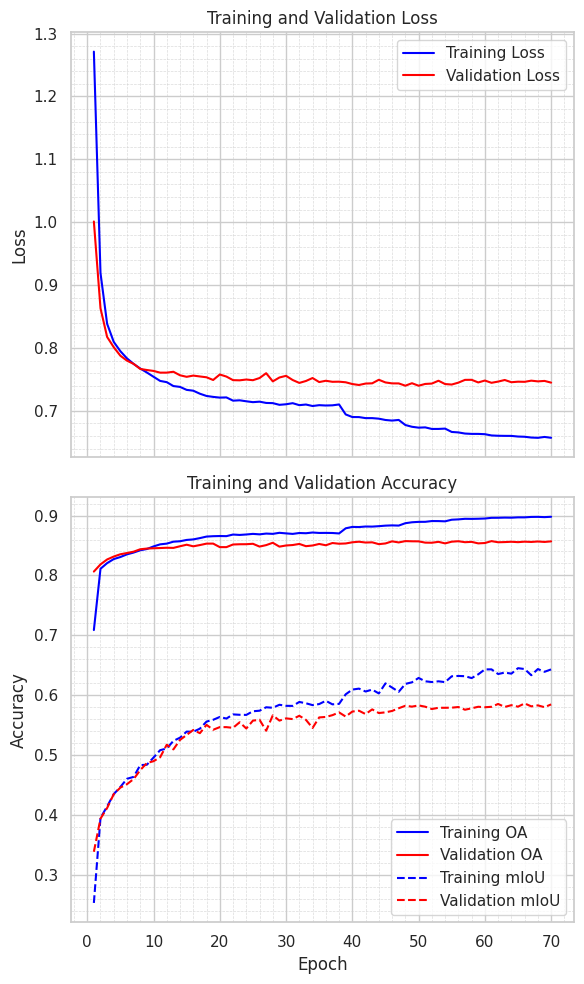

In [129]:
# Create plots for training and validation loss

fig, ax = plt.subplots(2, 1, figsize=(6, 10), sharex=True, sharey=False)


sns.lineplot(data=df_train, x="epoch", y="loss", markers="o",  label="Training Loss", ax = ax[0], color = 'blue')
sns.lineplot(data=df_val, x="epoch", y="loss", markers="x", label="Validation Loss", ax = ax[0], color='red')
ax[0].set_title("Training and Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

# Create plots for training and validation accuracy
sns.lineplot(data=df_train, x="epoch", y="accuracy", markers="o", label="Training OA", ax = ax[1], color = 'blue')
sns.lineplot(data=df_val, x="epoch", y="accuracy", markers="x", label="Validation OA", ax = ax[1], color='red')

sns.lineplot(data=df_train, x="epoch", y="mIoU", markers="x",linestyle = '--', label="Training mIoU", ax = ax[1], color = 'blue')
sns.lineplot(data=df_val, x="epoch", y="mIoU", markers="x",linestyle = '--', label="Validation mIoU", ax = ax[1], color='red')

ax[1].set_title("Training and Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()

# Add minor ticks to both axes
ax[0].minorticks_on()
ax[1].minorticks_on()

# Set gridlines for major and minor ticks
ax[0].grid(True, which='major', linestyle='-', linewidth=1)
ax[0].grid(True, which='minor', linestyle='--', linewidth=0.5, alpha=0.7)

ax[1].grid(True, which='major', linestyle='-', linewidth=1)
ax[1].grid(True, which='minor', linestyle='--', linewidth=0.5, alpha=0.7)

# Adjust layout and show the plot
plt.tight_layout()

# Save the figure
output_path = Path(path, r'loss_accuracy.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight', transparent=True)
# Save fig as pdf
output_path_pdf = output_path.with_suffix('.pdf')
plt.savefig(output_path_pdf, dpi=300, bbox_inches='tight', transparent=True)

plt.show()

# Completeness

In [105]:
# read the confision matrices in the path

confusion_matrices = []
for file in path.glob("confusion_matrix_*.csv"):
    df_cm = pd.read_csv(file, header = 0, index_col=0)
    confusion_matrices.append(df_cm)

In [106]:
def compute_metrics(confm):
    """
    Compute F1 score, precision, recall, and specificity from a confusion matrix.
    
    Args:
        confm (pd.DataFrame or np.ndarray): Confusion matrix with shape (n_classes, n_classes).
        
    Returns:
        tuple of arrays: (f1, precision, recall, specificity) for each class.
    """
    cm = confm.to_numpy() if isinstance(confm, pd.DataFrame) else confm
    n_classes = cm.shape[0]

    TP = np.diag(cm)
    FP = np.sum(cm, axis=0) - TP
    FN = np.sum(cm, axis=1) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    with np.errstate(divide='ignore', invalid='ignore'):
        precision = TP / (TP + FP)
        recall = TP / (TP + FN)
        specificity = TN / (TN + FP)
        f1 = 2 * precision * recall / (precision + recall)

        # Replace NaNs with 0s
        precision = np.nan_to_num(precision)
        recall = np.nan_to_num(recall)
        specificity = np.nan_to_num(specificity)
        f1 = np.nan_to_num(f1)

    return f1, precision, recall, specificity


In [107]:
f1_scores = []
precision_scores = []
recall_scores = []
specificity_scores = []

for i, cm in enumerate(confusion_matrices):
    f1, precision, recall, specificity = compute_metrics(cm)
    
    print(f"Confusion Matrix {i+1}:")
    for cls in range(len(f1)):
        print(f"  Class {cls}: F1={f1[cls]:.4f}, Precision={precision[cls]:.4f}, Recall={recall[cls]:.4f}, Specificity={specificity[cls]:.4f}")
    print()
    
    f1_scores.append(f1)
    precision_scores.append(precision)
    recall_scores.append(recall)
    specificity_scores.append(specificity)


Confusion Matrix 1:
  Class 0: F1=0.7941, Precision=0.7615, Recall=0.8296, Specificity=0.8247
  Class 1: F1=0.8550, Precision=0.8437, Recall=0.8667, Specificity=0.8070
  Class 2: F1=0.0000, Precision=0.0000, Recall=0.0000, Specificity=1.0000
  Class 3: F1=0.0000, Precision=0.0000, Recall=0.0000, Specificity=1.0000
  Class 4: F1=0.0000, Precision=0.0000, Recall=0.0000, Specificity=1.0000
  Class 5: F1=0.0000, Precision=0.0000, Recall=0.0000, Specificity=0.9996
  Class 6: F1=0.0000, Precision=0.0000, Recall=0.0000, Specificity=1.0000

Confusion Matrix 2:
  Class 0: F1=0.7411, Precision=0.7422, Recall=0.7400, Specificity=0.8266
  Class 1: F1=0.8376, Precision=0.8009, Recall=0.8778, Specificity=0.7378
  Class 2: F1=0.0000, Precision=0.0000, Recall=0.0000, Specificity=1.0000
  Class 3: F1=0.0000, Precision=0.0000, Recall=0.0000, Specificity=1.0000
  Class 4: F1=0.0000, Precision=0.0000, Recall=0.0000, Specificity=1.0000
  Class 5: F1=0.0000, Precision=0.0000, Recall=0.0000, Specificity=0.99

In [108]:
# Convert lists to numpy arrays for easier manipulation
f1_scores = np.array(f1_scores)
precision_scores = np.array(precision_scores)
recall_scores = np.array(recall_scores)
specificity_scores = np.array(specificity_scores)

In [109]:
classes_names = ['Pasture', 'Arboreal', 'Agriculture', 'Mining', 'Building', 'Water', 'Other']

In [110]:
# Convert f1 to dataframe
f1_df = pd.DataFrame(f1_scores, columns=[f'Class {i}' for i in range(f1_scores.shape[1])])
precision_df = pd.DataFrame(precision_scores, columns=[f'Class {i}' for i in range(precision_scores.shape[1])])
recall_df = pd.DataFrame(recall_scores, columns=[f'Class {i}' for i in range(recall_scores.shape[1])])
specificity_df = pd.DataFrame(specificity_scores, columns=[f'Class {i}' for i in range(specificity_scores.shape[1])])

# Rename columns with class names
f1_df.columns = classes_names
precision_df.columns = classes_names
recall_df.columns = classes_names
specificity_df.columns = classes_names

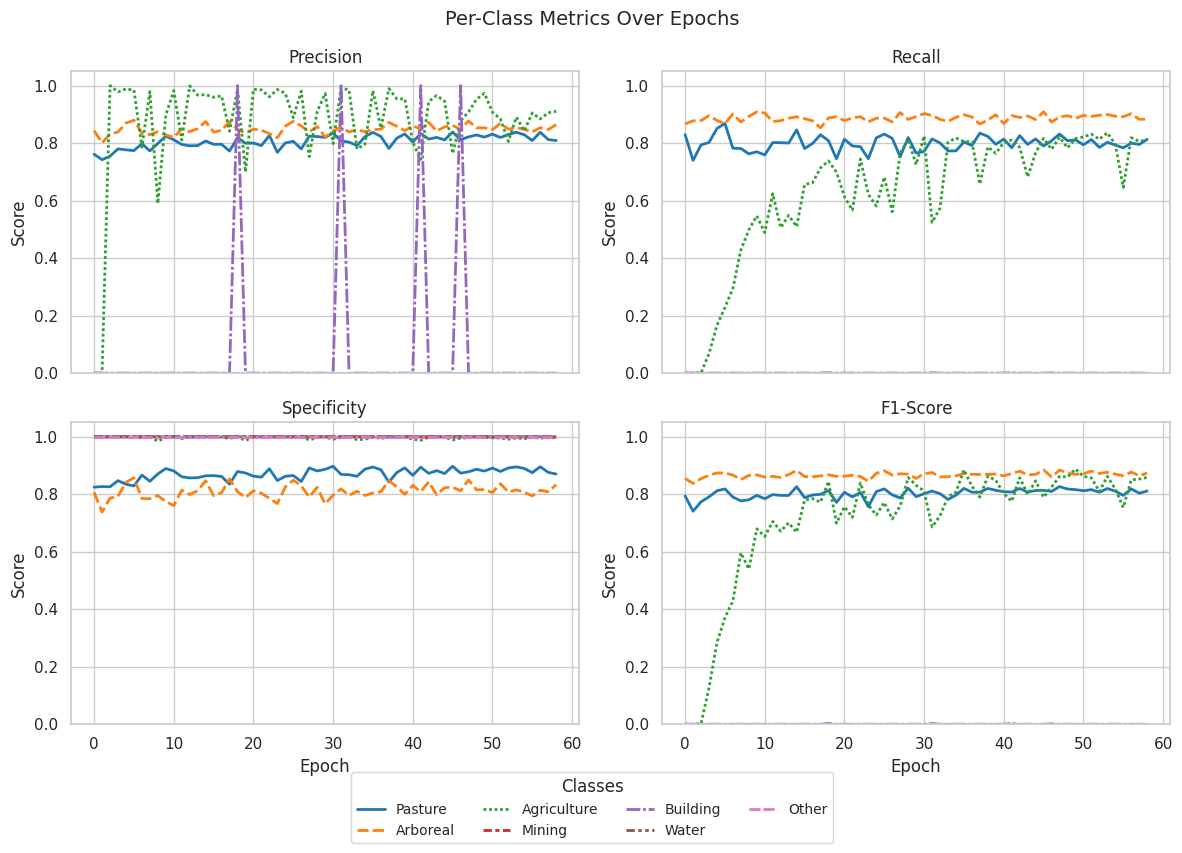

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 8), sharex=True)

metrics = {
    "Precision": precision_df,
    "Recall": recall_df,
    "Specificity": specificity_df,
    "F1-Score": f1_df,
}
axes = [ax[0, 0], ax[0, 1], ax[1, 0], ax[1, 1]]

# Use one axis to get the legend info (temporarily with legend=True)
temp_axis = axes[0]
plot = sns.lineplot(data=list(metrics.values())[0], ax=temp_axis, palette="tab10", linewidth=2)
handles, labels = temp_axis.get_legend_handles_labels()
temp_axis.clear()  # Clear to replot without legend below

# Now plot all without internal legends
for (name, df), axis in zip(metrics.items(), axes):
    sns.lineplot(data=df, ax=axis, palette="tab10", linewidth=2, legend=False)
    axis.set_title(name)
    axis.set_ylabel("Score")
    axis.set_xlabel("Epoch")
    axis.set_ylim(0, 1.05)
    axis.grid(True, which='major', linestyle='-', linewidth=1)
    axis.grid(True, which='minor', linestyle='--', linewidth=0.5, alpha=0.7)
    

# Shared legend below
fig.legend(handles, labels, title="Classes", loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.07), fontsize='small')

plt.suptitle("Per-Class Metrics Over Epochs", fontsize=14)
plt.tight_layout()  # Leave space for the suptitle and legend


# Save the figure
output_path = Path(path, r'completeness.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight', transparent=True)
# Save fig as pdf
output_path_pdf = output_path.with_suffix('.pdf')
plt.savefig(output_path_pdf, dpi=300, bbox_inches='tight', transparent=True)

plt.show()